# Music Sequence Similarity

#### Import required modules.

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

#### Load the comparison data and reference data.

In [6]:
y_ref, sr = librosa.load("C:\Users\monik\Documents\Paris\Internship\Analyses\Pilot-Data\111\Improv\111_recording_mic_1_2023-03-21_15h26.52.823.wav") # reference
y_comp, sr = librosa.load("C:\Users\monik\Documents\Paris\Internship\Analyses\Pilot-Data\999\Improv\999_recording_mic_1_2023.wav") # comparison

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (2380348709.py, line 1)

#### Transform the audio data to get suitable input for matrix computation.

In [3]:
hop_length = 1024

chroma_ref = librosa.feature.chroma_cqt(y=y_ref, sr=sr, hop_length=hop_length)
chroma_comp = librosa.feature.chroma_cqt(y=y_comp, sr=sr, hop_length=hop_length)

# Use time-delay embedding to get a cleaner recurrence matrix
x_ref = librosa.feature.stack_memory(chroma_ref, n_steps=10, delay=3)
x_comp = librosa.feature.stack_memory(chroma_comp, n_steps=10, delay=3)

#### Compute the similarity matrices.

In [4]:
xsim = librosa.segment.cross_similarity(x_comp, x_ref, metric='cosine') # cosine connectivity
xsim_aff = librosa.segment.cross_similarity(x_comp, x_ref, metric='cosine', mode='affinity') # affinity

#### Plot the matrices.

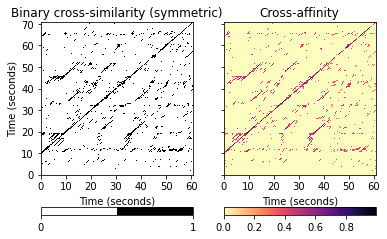

In [5]:
fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
imgsim = librosa.display.specshow(xsim, x_axis='s', y_axis='s',
                         hop_length=hop_length, ax=ax[0])
ax[0].set(title='Binary cross-similarity (symmetric)')
imgaff = librosa.display.specshow(xsim_aff, x_axis='s', y_axis='s',
                         cmap='magma_r', hop_length=hop_length, ax=ax[1])
ax[1].set(title='Cross-affinity')
ax[1].label_outer()
fig.colorbar(imgsim, ax=ax[0], orientation='horizontal', ticks=[0, 1])
fig.colorbar(imgaff, ax=ax[1], orientation='horizontal')